# Check radiation and cloud fields

In [2]:
import xarray as xr
import numpy as np
import glob
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import utils
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/')
import utils

In [3]:
# --- Settings ---
root_dir = "/g/data/eg3/nesp_bff/"
loc = "Canberra"
barra_version = "BARRA-R2"
cities = ["Melbourne", "Darwin", "Cairns","Brisbane","Longreach","Mildura","Adelaide","Perth","Sydney","Canberra","Hobart"]
variables = ["rsds", "rsdsdir","clt"]
var = "tas"

In [5]:
# --- Read data ---
# NatHERS processed
ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0])
offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)#.sel(time=slice("1990","2014"))
# print(ds_nathers_local)

# NatHERS raw
ds_nathers_raw =  xr.open_dataset(glob.glob(f"/g/data/eg3/spr548/projects/nesp_bff/data/raw_data/NatHERS/historical/{loc}_*_NatHERS_*.nc")[0])

# BARRA raw
ds_barra_raw = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{barra_version}/{loc}_"
                                   f"AUS-11_ERA5_historical_hres_BOM_{barra_version}_v1_1hr_"
                                   f"1985-2014.nc")#.sel(time=slice("1990","2014")).load()
ds_barra_raw_time_utc = pd.to_datetime(ds_barra_raw.time.values).tz_localize('UTC')
ds_barra_raw_time_utc_to_local = ds_barra_raw_time_utc.tz_convert(f'Australia/{loc}').tz_localize(None)
ds_barra_raw_local = ds_barra_raw.copy()
ds_barra_raw_local = ds_barra_raw_local.assign_coords(time=ds_barra_raw_time_utc_to_local)
ds_barra_raw_local = utils.fix_duplicate_times(ds_barra_raw_local)
# print(ds_barra_raw_local)

# BARRA adjusted
ds_barra_adj = xr.open_dataset(f"{root_dir}step2_qdc_scaling/{barra_version}/{loc}_AUS-11_ERA5_historical_hres_BOM_"
                         f"{barra_version}_v1_1hr_1990-2014_QDC-NatHERS.nc")
# print(ds_barra_adj)

Found 30 duplicate time entries.
Duplicates removed.


In [6]:
# Align by time
nathers, barra_raw, barra_adj = xr.align(ds_nathers_local, ds_barra_raw_local, ds_barra_adj, join="inner")
print(nathers, barra_raw, barra_adj)

<xarray.Dataset> Size: 37MB
Dimensions:                 (time: 219119)
Coordinates:
  * time                    (time) datetime64[ns] 2MB 1990-01-01 ... 2014-12-...
    lat                     float64 8B ...
    lon                     float64 8B ...
    time_offset             float64 8B 10.0
    round_method            float64 8B ...
Data variables: (12/20)
    tas                     (time) float64 2MB ...
    huss                    (time) float64 2MB ...
    psl                     (time) float64 2MB ...
    sfcWind                 (time) float64 2MB ...
    wind_dir                (time) float64 2MB ...
    flag-tas                (time) float64 2MB ...
    ...                      ...
    slr_alt                 (time) float64 2MB ...
    slr_azm                 (time) float64 2MB ...
    flag-rsds               (time) float64 2MB ...
    flag-rsdsdif            (time) float64 2MB ...
    flag-rsdsdir            (time) float64 2MB ...
    clt                     (time) float64 2

## Cloud cover

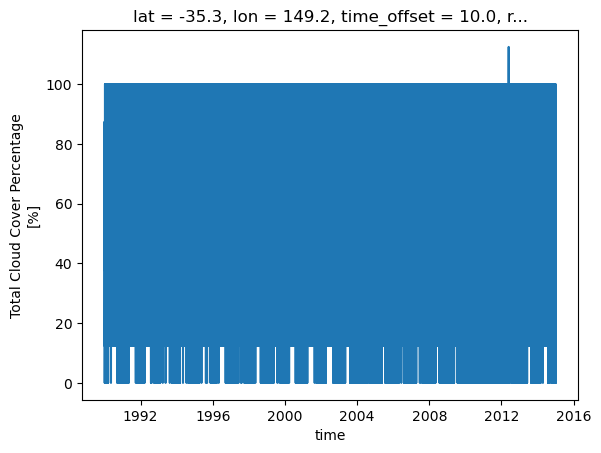

In [49]:
nathers.clt.plot()

In [80]:
# print(nathers.clt.where(nathers.clt==112.5).count())
# Find the maximum value
# Find the maximum clt value
max_val = nathers.clt.max().item()

# Find the time(s) where that maximum occurs
max_times = nathers.time.where(nathers.clt == max_val, drop=True)
nathers_max = nathers[['clt', 'flag-total_cloud_cover']].sel(time=max_times)
df_max = nathers_max.to_dataframe().reset_index()

df_max
# print(nathers.data_vars)


,time,clt,flag-total_cloud_cover,lat,lon,time_offset,round_method
0,2012-05-27 09:00:00,112.5,0.0,-35.305,149.201,10.0,NaN


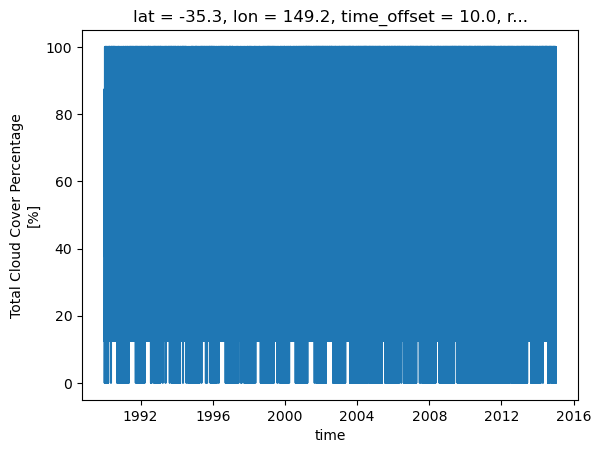

In [51]:
nathers_clt_clip = nathers.clt.clip(0,100)
nathers_clt_clip.plot()

In [52]:
print(np.unique(nathers_clt_clip.values))
print(np.unique(barra_raw.clt.values))

[  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]
[0.00000000e+00 3.90625000e-03 5.85937500e-03 ... 9.99941406e+01
 9.99960938e+01 1.00000000e+02]


(array([38326.,  5938.,  8023.,  8950., 15913., 16378., 26188., 22917.,
        22022., 54464.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

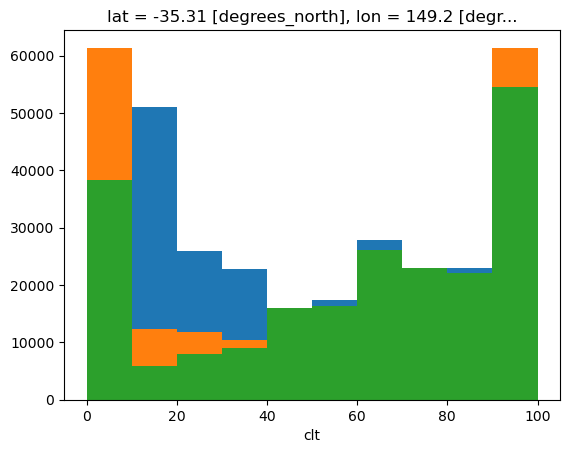

In [55]:
nathers_clt_clip.plot.hist() #sel(time="2000-01-01")
barra_raw.clt.plot.hist()
barra_adj.clt.plot.hist()

In [8]:
def cloud_frac_to_oktas(clt_frac):
    bins = [-0.1,1,12.5,25,37.5,50,52.5,75,87.5,100.1]
    # oktas = np.arange(0,9) # 0 to 8

    return xr.apply_ufunc(
        lambda x: np.digitize(x, bins) -1,
        clt_frac,
        input_core_dims=[[]],
        output_core_dims=[[]],
        vectorize=True,
        output_dtypes=[int]
    ).rename('Total_cloud_cover')

In [59]:
# barra_clt_oktas = cloud_frac_to_oktas(barra_raw.clt)
# barra_clt_oktas_frac = barra_clt_oktas*12.5
# print(np.unique(barra_clt_oktas.values))
# print(np.unique(nathers_clt_clip.values))

In [61]:
# print(nathers_clt_clip.sel(time="2000-01-01").values)
# print(barra_clt_oktas_frac.sel(time="2000-01-01").values)

In [68]:
# Clip to valid range
barra_clt_clip = barra_raw.clt.clip(0, 100)
bins = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100., 112.5])

def assign_to_left_bin(x, bins):
    """Assign each x to its left bin edge."""
    idx = np.digitize(x, bins, right=False) - 1  # shift to get left edge index
    idx = np.clip(idx, 0, len(bins) - 2)         # prevent overflow
    return bins[idx]

# Apply with vectorization and dask support
barra_clt_binned = xr.apply_ufunc(
    assign_to_left_bin,
    barra_clt_clip,
    kwargs={"bins": bins},
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)


In [ ]:
# import pandas as pd
# import numpy as np
 
# def oktas_to_fraction(df, col='oktas', new_col='cloud_frac', method='linear', drop_oktas=False):
#     """
#     Convert a column of oktas (0-8) to cloud fraction (0-100%) in a DataFrame.
 
#     Parameters
#     ----------
#     df : pandas.DataFrame
#         Input DataFrame.
#     col : str
#         Name of the column containing oktas.
#     new_col : str
#         Name of the new column to store cloud fraction.
#     method : str
#         Conversion method: 
#         - 'linear': 0->0%, 8->100%, intermediate evenly spaced
#         - 'midpoint': map to midpoint of each okta bin
#     drop_oktas : bool
#         If True, drop the original oktas column from the DataFrame.
 
#     Returns
#     -------
#     pandas.DataFrame
#         DataFrame with the new column added (and optionally original column removed).
#     """
#     if method == 'linear':
#         df[new_col] = df[col] / 8 * 100
#     elif method == 'midpoint':
#         midpoints = np.array([0, 6.25, 18.75, 31.25, 43.75, 56.25, 68.75, 81.25, 93.75])
#         df[new_col] = midpoints[df[col].values.astype(int)]
#     else:
#         raise ValueError("method must be 'linear' or 'midpoint'")
#     if drop_oktas:
#         df.drop(columns=[col], inplace=True)
#     return df

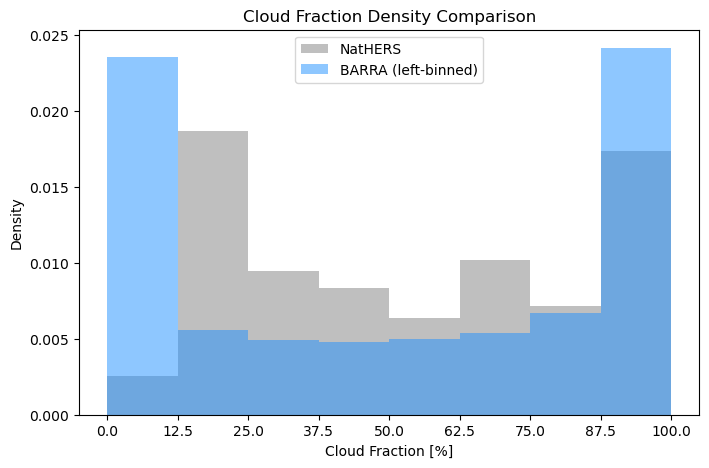

In [71]:
bin_edges = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100.])
plt.figure(figsize=(8, 5))

nathers_clt_clip.plot.hist(bins=8,density=True,alpha=0.5,label='NatHERS',color='gray')
barra_clt_binned.plot.hist(bins=8,density=True,alpha=0.5,label='BARRA (left-binned)',color='dodgerblue')

plt.title('Cloud Fraction Density Comparison')
plt.xlabel('Cloud Fraction [%]')
plt.ylabel('Density')
plt.legend()
plt.xticks(bin_edges)
# plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


## Radiation

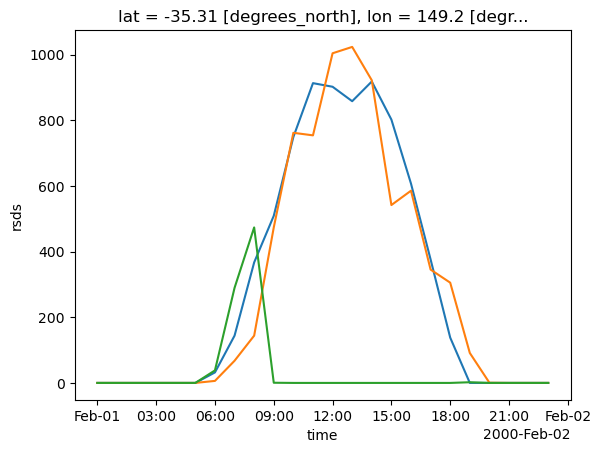

In [7]:
nathers.sel(time="2000-02-01").rsds.plot() #blue
barra_raw.sel(time="2000-02-01").rsds.plot() #orange
barra_adj.sel(time="2000-02-01").rsds.plot() #green

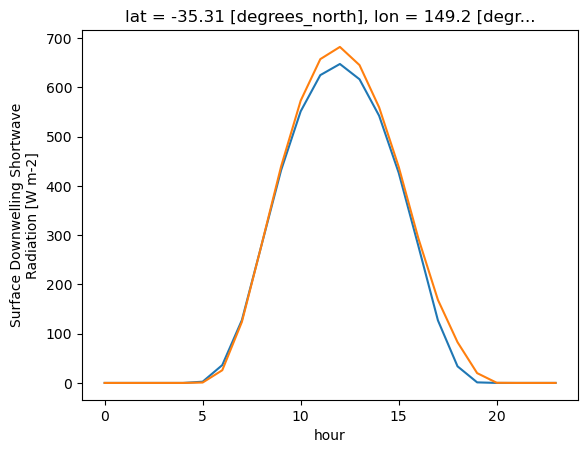

In [11]:
nathers.rsds.sel(time=slice("1995","2014")).groupby("time.hour").mean("time").plot() #blue
barra_raw.rsds.sel(time=slice("1995","2014")).groupby("time.hour").mean("time").plot() #orange
# barra_raw.sel(time="2000-02-01").rsds.plot() #orange
# barra_adj.sel(time="2000-02-01").rsds.plot() #green

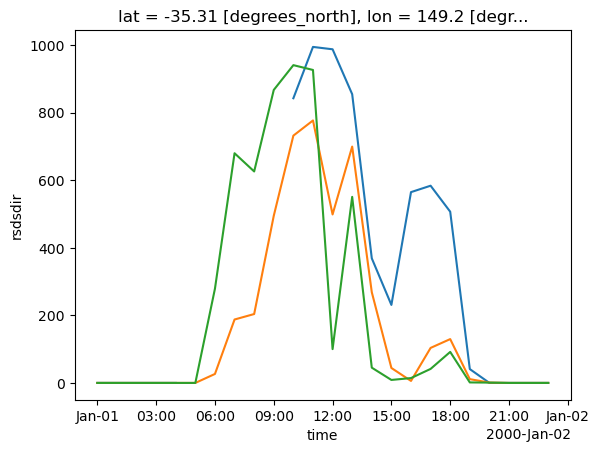

In [9]:
nathers.sel(time="2000-01-01").rsdsdir.plot()
barra_raw.sel(time="2000-01-01").rsdsdir.plot()
barra_adj.sel(time="2000-01-01").rsds.plot()